In [1]:
!nvidia-smi

Tue Nov 18 19:34:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import libraries

In [2]:
!git clone https://github.com/VuTrinhNguyenHoang/eX-LAViTs.git

Cloning into 'eX-LAViTs'...
remote: Enumerating objects: 432, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 432 (delta 47), reused 53 (delta 24), pack-reused 351 (from 1)
Receiving objects: 100% (432/432), 171.19 KiB | 9.01 MiB/s, done.
Resolving deltas: 100% (275/275), done.


In [3]:
%cd eX-LAViTs
!ls -l

/kaggle/working/eX-LAViTs
total 28
drwxr-xr-x 2 root root 4096 Nov 18 19:34 configs
drwxr-xr-x 2 root root 4096 Nov 18 19:34 datasets
drwxr-xr-x 2 root root 4096 Nov 18 19:34 notebooks
-rw-r--r-- 1 root root  315 Nov 18 19:34 README.md
-rw-r--r-- 1 root root   93 Nov 18 19:34 requirements.txt
drwxr-xr-x 4 root root 4096 Nov 18 19:34 src
drwxr-xr-x 2 root root 4096 Nov 18 19:34 tests


In [4]:
# Repository
from src.models.linear_vit import create_linear_attention_vit
from src.models.explainability import ViTGradCAM, IntegratedGradient, Rollout, LAGRA
from src.utils.training import (
    create_run_directory, setup_logging, get_optimizer, get_scheduler,
    train_model, count_parameters, load_checkpoint
)
from src.pretrained import freeze_all_except_last_k_blocks, unfreeze_all
from src.utils.metrics import compute_loss_and_accuracy, compute_classification_metrics, evaluate_xai_method_dataset, evaluate_class_specificity_cosine
from src.utils.visualization import save_all_plots, create_training_summary_plot
from src.explain import visualize_methods
from datasets import get_cifar100_dataloaders, get_cifar10_dataloaders

# Pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.transforms.autoaugment import AutoAugment, AutoAugmentPolicy
import timm
from sklearn.model_selection import train_test_split

from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import math
from tqdm.auto import tqdm
import os

## Config

In [5]:
run_name = "run001"

LR = 1e-4
WD = 1e-4

EPOCHS = 100
warmup_epochs = 10
remaining_epochs = EPOCHS - warmup_epochs

PATIENCE = 5

BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
print(NUM_WORKERS, DEVICE)

4 cuda


## Datasets

In [6]:
train_loader, valid_loader, test_loader = get_cifar10_dataloaders(batch_size=BATCH_SIZE)

len(train_loader), len(valid_loader), len(test_loader)

100%|██████████| 170M/170M [00:04<00:00, 34.2MB/s]


(703, 79, 157)

In [7]:
batch_test = next(iter(train_loader))
batch_test[0].shape, batch_test[1].shape

(torch.Size([64, 3, 32, 32]), torch.Size([64]))

## Train model

In [8]:
model_name = "vit_tiny_patch16_224"

model = create_linear_attention_vit(
    model_name,
    pretrained=True,
    num_classes=10,
    img_size=32,
    drop_path_rate=0.1,
    attn_drop_rate=0.1,
    proj_drop_rate=0.1,
)

Creating Linear Attention ViT: vit_tiny_patch16_224
    Pretrained: True
    Classes: 10
    Image size: 32


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

    Original parameters: 5,489,482
Replacing attention layers with LinearMultiheadAttention...
    Kernel: elu
    Epsilon: 1e-06
   Block 0: dim=192, heads=3, mlp_ratio=4.0
   Block 1: dim=192, heads=3, mlp_ratio=4.0
   Block 2: dim=192, heads=3, mlp_ratio=4.0
   Block 3: dim=192, heads=3, mlp_ratio=4.0
   Block 4: dim=192, heads=3, mlp_ratio=4.0
   Block 5: dim=192, heads=3, mlp_ratio=4.0
   Block 6: dim=192, heads=3, mlp_ratio=4.0
   Block 7: dim=192, heads=3, mlp_ratio=4.0
   Block 8: dim=192, heads=3, mlp_ratio=4.0
   Block 9: dim=192, heads=3, mlp_ratio=4.0
   Block 10: dim=192, heads=3, mlp_ratio=4.0
   Block 11: dim=192, heads=3, mlp_ratio=4.0
Successfully replaced 12 attention blocks
    Total parameters: 5,489,482
    Trainable parameters: 5,489,482


In [9]:
run_dir = create_run_directory("experiments", run_name)
print(f"Created run directory: {run_dir}")

logger = setup_logging(os.path.join(run_dir, 'logs'))
logger.info(f"Starting training with {run_name}")
logger.info(f"Using device: {DEVICE}")

logger.info(f"Train batches: {len(train_loader)}")
logger.info(f"Validation batches: {len(valid_loader)}")
logger.info(f"Test batches: {len(test_loader)}")

model = model.to(DEVICE)
total_params, trainable_params = count_parameters(model)
logger.info(f"Model loaded with {total_params:,} total parameters ({trainable_params:,} trainable)")

criterion = nn.CrossEntropyLoss()
logger.info("Starting training...")

2025-11-18 19:35:23 - training - INFO - Starting training with run001
2025-11-18 19:35:23 - training - INFO - Using device: cuda
2025-11-18 19:35:23 - training - INFO - Train batches: 703
2025-11-18 19:35:23 - training - INFO - Validation batches: 79
2025-11-18 19:35:23 - training - INFO - Test batches: 157
2025-11-18 19:35:23 - training - INFO - Model loaded with 5,489,482 total parameters (5,489,482 trainable)
2025-11-18 19:35:23 - training - INFO - Starting training...


Created run directory: experiments/run001


In [10]:
if warmup_epochs > 0:
    logger.info(f"Phase 1: Warm-up last 4 blocks for {warmup_epochs} epochs")
    freeze_all_except_last_k_blocks(model, k=4, logger=logger)
    optimizer1 = get_optimizer(
        model,
        optimizer_name="adamw",
        learning_rate=LR * 0.5,
        weight_decay=WD,
    )
    scheduler1 = get_scheduler(
        optimizer1, 
        "cosine", 
        **{
            "T_max": warmup_epochs,
            "eta_min": 0
        }
    )

    metrics_phase1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=optimizer1,
        scheduler=scheduler1,
        device=DEVICE,
        num_epochs=warmup_epochs,
        run_dir=run_dir,
        save_freq=50,
        print_freq=50,
        early_stopping_patience=PATIENCE,
        logger=logger
    )
    logger.info("Phase 1 completed.")

2025-11-18 19:35:23 - training - INFO - Phase 1: Warm-up last 4 blocks for 10 epochs
2025-11-18 19:35:23 - training - INFO - [Warmup] Trainable params with last 4 blocks: 2,967,562
2025-11-18 19:35:23 - training - INFO - Starting epoch 1/10
2025-11-18 19:35:24 - training - INFO - Epoch: [1][0/703]	Time 1.280 (1.280)	Loss 2.7828 (2.7828)	Acc@1 12.500 (12.500)	Memory 1690MB
2025-11-18 19:35:27 - training - INFO - Epoch: [1][50/703]	Time 0.042 (0.071)	Loss 2.2458 (2.3956)	Acc@1 15.625 (10.294)	Memory 1691MB
2025-11-18 19:35:29 - training - INFO - Epoch: [1][100/703]	Time 0.054 (0.060)	Loss 2.1454 (2.3314)	Acc@1 21.875 (12.748)	Memory 1691MB
2025-11-18 19:35:32 - training - INFO - Epoch: [1][150/703]	Time 0.045 (0.055)	Loss 2.1735 (2.2598)	Acc@1 23.438 (15.925)	Memory 1691MB
2025-11-18 19:35:34 - training - INFO - Epoch: [1][200/703]	Time 0.036 (0.053)	Loss 1.9732 (2.1885)	Acc@1 23.438 (18.618)	Memory 1691MB
2025-11-18 19:35:36 - training - INFO - Epoch: [1][250/703]	Time 0.044 (0.051)	Los

In [11]:
if remaining_epochs > 0:
    logger.info(f"Phase 2: Unfreeze last 8 blocks and finetune for {remaining_epochs} epochs")
    freeze_all_except_last_k_blocks(model, k=8, logger=logger)
    optimizer2 = get_optimizer(
        model,
        optimizer_name="adamw",
        learning_rate=LR,
        weight_decay=WD,
    )
    scheduler2 = get_scheduler(
        optimizer2, 
        "cosine", 
        **{
            "T_max": remaining_epochs,
            "eta_min": 0
        }
    )

    metrics_phase2 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=optimizer2,
        scheduler=scheduler2,
        device=DEVICE,
        num_epochs=remaining_epochs,
        run_dir=run_dir,
        save_freq=50,
        print_freq=50,
        early_stopping_patience=PATIENCE,
        logger=logger
    )
    logger.info("Phase 2 completed.")

2025-11-18 19:41:03 - training - INFO - Phase 2: Unfreeze last 8 blocks and finetune for 90 epochs
2025-11-18 19:41:03 - training - INFO - [Warmup] Trainable params with last 8 blocks: 4,154,122
2025-11-18 19:41:03 - training - INFO - Starting epoch 1/90
2025-11-18 19:41:04 - training - INFO - Epoch: [1][0/703]	Time 0.320 (0.320)	Loss 1.2234 (1.2234)	Acc@1 54.688 (54.688)	Memory 1695MB
2025-11-18 19:41:06 - training - INFO - Epoch: [1][50/703]	Time 0.043 (0.052)	Loss 1.4844 (1.4268)	Acc@1 43.750 (48.192)	Memory 1695MB
2025-11-18 19:41:09 - training - INFO - Epoch: [1][100/703]	Time 0.044 (0.050)	Loss 1.5319 (1.4129)	Acc@1 46.875 (48.840)	Memory 1695MB
2025-11-18 19:41:11 - training - INFO - Epoch: [1][150/703]	Time 0.044 (0.049)	Loss 1.2978 (1.4126)	Acc@1 48.438 (48.903)	Memory 1695MB
2025-11-18 19:41:13 - training - INFO - Epoch: [1][200/703]	Time 0.056 (0.048)	Loss 1.6661 (1.4333)	Acc@1 42.188 (48.041)	Memory 1695MB
2025-11-18 19:41:16 - training - INFO - Epoch: [1][250/703]	Time 0.0

## Evaluate

In [12]:
logger.info("Training completed!")

# Evaluate on test setlogger.info("Evaluating on test set...")
test_results = compute_loss_and_accuracy(
    model, test_loader, criterion, DEVICE, return_predictions=True
)

# Compute detailed classification metrics
classification_metrics = compute_classification_metrics(
    test_results['predictions'],
    test_results['targets'],
    return_confusion_matrix=True
)

# Log test results
logger.info(f"Test Results:")
logger.info(f"  Loss: {test_results['loss']:.4f}")
logger.info(f"  Top-1 Accuracy: {test_results['top1_accuracy']:.2f}%")
logger.info(f"  Macro F1-Score: {classification_metrics['macro_f1']:.2f}%")
logger.info(f"  Weighted F1-Score: {classification_metrics['weighted_f1']:.2f}%")

2025-11-18 20:19:50 - training - INFO - Training completed!
2025-11-18 20:19:52 - training - INFO - Test Results:
2025-11-18 20:19:52 - training - INFO -   Loss: 0.7149
2025-11-18 20:19:52 - training - INFO -   Top-1 Accuracy: 75.14%
2025-11-18 20:19:52 - training - INFO -   Macro F1-Score: 74.97%
2025-11-18 20:19:52 - training - INFO -   Weighted F1-Score: 74.97%


2025-11-18 20:19:52 - training - INFO - Generating plots...


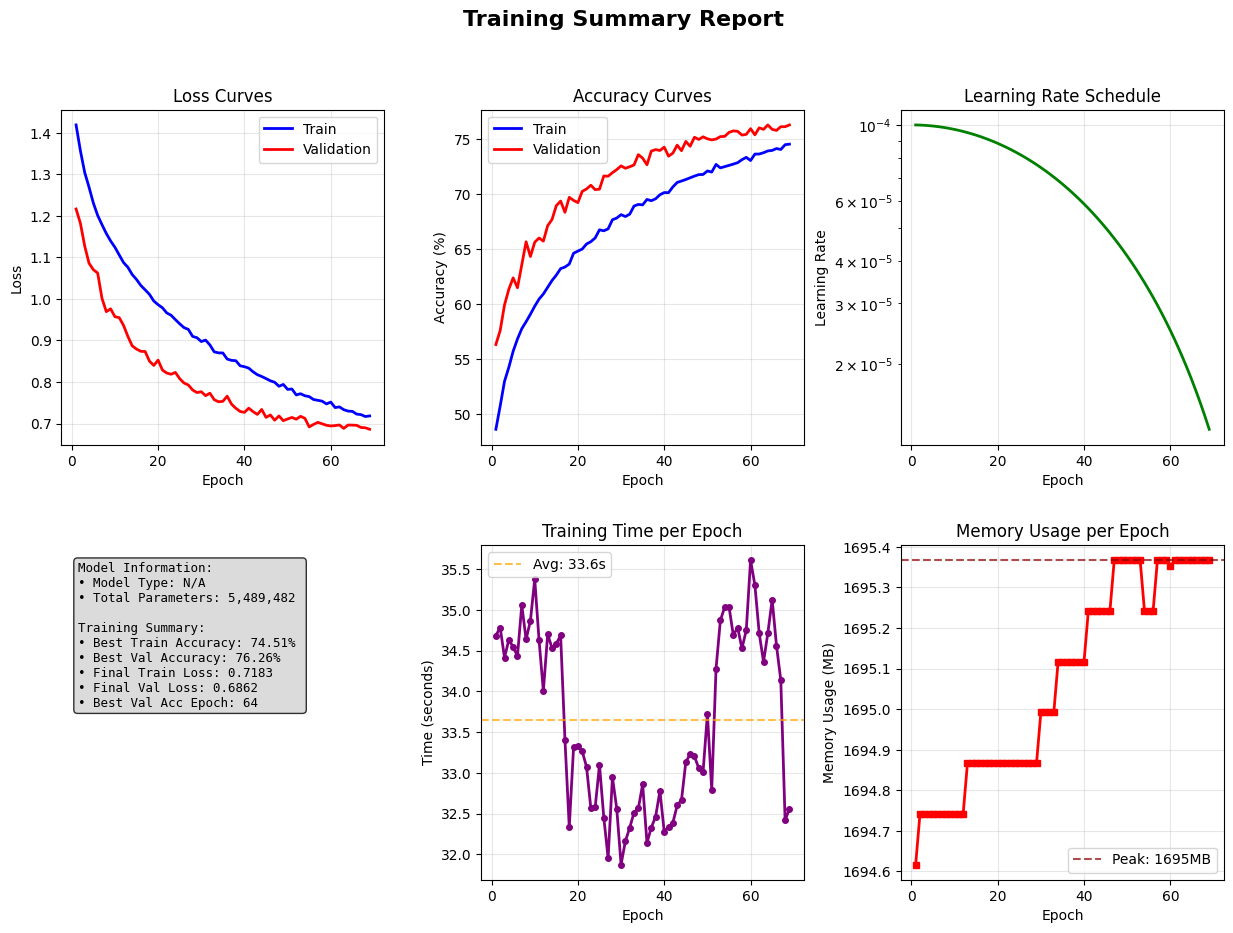

In [13]:
# Generate and save plots
logger.info("Generating plots...")
save_all_plots(
    metrics_tracker=metrics_phase2,
    run_dir=run_dir,
    y_true=test_results['targets'],
    y_pred=test_results['predictions'],
)

# Create comprehensive training summary plot
model_info = {
    'model_name': model_name,
    'total_params': total_params,
}

summary_plot = create_training_summary_plot(metrics_phase2, model_info)
summary_plot.savefig(
    os.path.join(run_dir, 'plots', 'training_summary.png'),
    bbox_inches='tight', dpi=300
)

## Explain

In [14]:
model.to(DEVICE).eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): LinearAttentionBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): LinearMultiheadAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (out_proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.1, inplace=False)
        (attn_drop): Dropout(p=0.1, inplace=False)
      )
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.1, inplace=False)
        (fc2): Linear(in_features=768, out_features=192, bias=True)
       

In [15]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

### LAGRA

In [16]:
test_dataset = test_loader.dataset

idx = np.random.randint(len(test_dataset))

x, y_true = test_dataset[idx] # test sample
xb = x.unsqueeze(0).to(DEVICE)

In [17]:
proposal_model = LAGRA(model, has_cls=True, blocks_attr="blocks")

out = proposal_model.attribute(xb, use_logits=True)

In [18]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 4]),
 torch.Size([1, 1, 32, 32]),
 tensor(0.5730, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.4013, device='cuda:0', grad_fn=<MeanBackward0>))

### GradCAM

In [19]:
gradcam_model = ViTGradCAM(model, has_cls=True)

out = gradcam_model.attribute(xb)

In [20]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 4]),
 torch.Size([1, 1, 32, 32]),
 tensor(0.9096, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.4357, device='cuda:0', grad_fn=<MeanBackward0>))

### Integrated Gradients

In [21]:
ig_model = IntegratedGradient(model, m_steps=32)

out = ig_model.attribute(xb)

In [22]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 4]),
 torch.Size([1, 1, 32, 32]),
 tensor(0.8491, device='cuda:0'),
 tensor(0.0952, device='cuda:0'))

### Rollout

In [23]:
rollout_model = Rollout(model, has_cls=True)

out = rollout_model.attribute(xb)

In [24]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 4]),
 torch.Size([1, 1, 32, 32]),
 tensor(0.9088, device='cuda:0'),
 tensor(0.5586, device='cuda:0'))

## Visualization

860


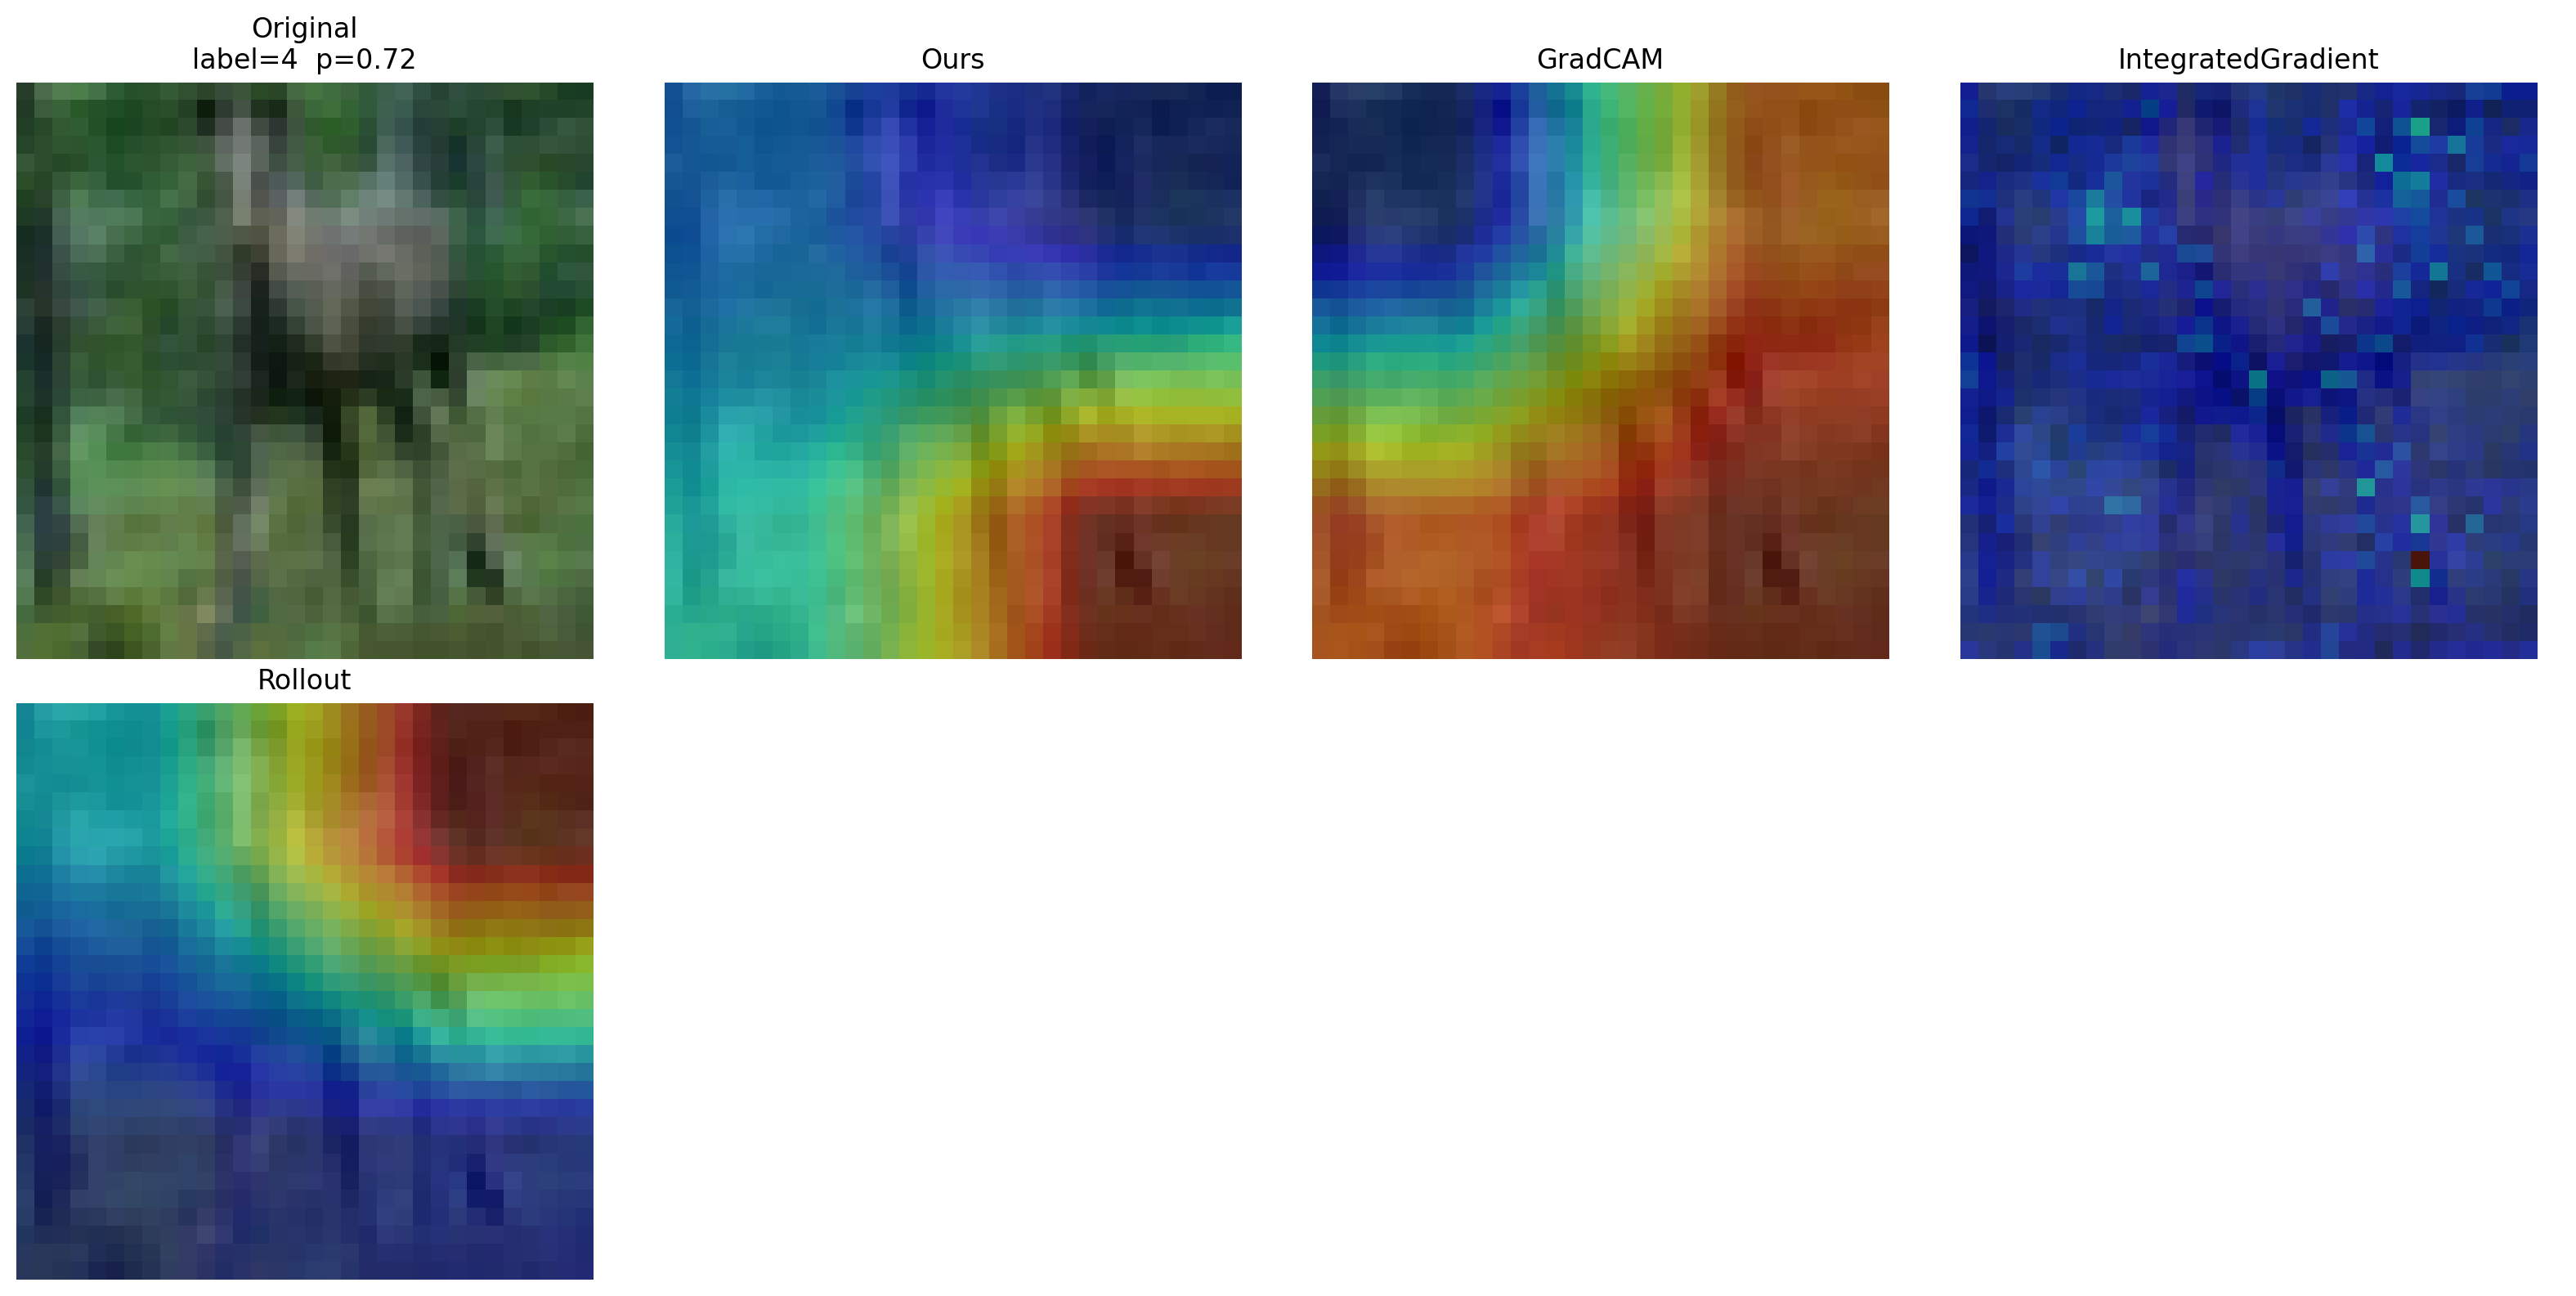

In [25]:
idx = np.random.randint(len(test_dataset))
print(idx)

_ = visualize_methods(
    test_dataset, idx,
    {
        "Ours": proposal_model,
        "GradCAM": gradcam_model,
        "IntegratedGradient": ig_model,
        "Rollout": rollout_model
    },
    use_pred=True,
    device=DEVICE,
)

## Evaluate Explain methods

In [26]:
methods = {
    "Ours": proposal_model,
    "GradCAM": gradcam_model,
    "IG": ig_model,
    "Rollout": rollout_model
}

results = {}
for name, attr in methods.items():
    print(f"Evaluating {name}...")
    stats_faith = evaluate_xai_method_dataset(
        attributor=attr,
        dataset=test_dataset,
        device=DEVICE,
        use_pred=True,
        max_samples=640,
        steps=20,
        baseline=None,
        use_logits=True,
        verbose_every=50,
    )

    stats_cs = evaluate_class_specificity_cosine(
        attributor=attr,
        dataset=test_dataset,
        device=DEVICE,
        max_samples=640,
        use_logits=True,
        use_pred=True,
        verbose_every=50,
    )

    metrics = {
        **stats_faith,
        "cosine_cs_mean": stats_cs["cosine_cs_mean"],
        "cosine_cs_std": stats_cs["cosine_cs_std"],
    }
    results[name] = metrics
    print(f"Results for {name}: {metrics}")
    print("-" * 50)

Evaluating Ours...
[50/640] AUC_del_mean=0.4604, AUC_ins_mean=0.5362, entropy_mean=0.9022
[100/640] AUC_del_mean=0.4734, AUC_ins_mean=0.5766, entropy_mean=0.9116
[150/640] AUC_del_mean=0.4896, AUC_ins_mean=0.6012, entropy_mean=0.9131
[200/640] AUC_del_mean=0.4825, AUC_ins_mean=0.5930, entropy_mean=0.9084
[250/640] AUC_del_mean=0.4774, AUC_ins_mean=0.5901, entropy_mean=0.9093
[300/640] AUC_del_mean=0.4862, AUC_ins_mean=0.5947, entropy_mean=0.9105
[350/640] AUC_del_mean=0.4823, AUC_ins_mean=0.5940, entropy_mean=0.9102
[400/640] AUC_del_mean=0.4799, AUC_ins_mean=0.5900, entropy_mean=0.9104
[450/640] AUC_del_mean=0.4760, AUC_ins_mean=0.5885, entropy_mean=0.9097
[500/640] AUC_del_mean=0.4796, AUC_ins_mean=0.5895, entropy_mean=0.9099
[550/640] AUC_del_mean=0.4770, AUC_ins_mean=0.5865, entropy_mean=0.9110
[600/640] AUC_del_mean=0.4825, AUC_ins_mean=0.5891, entropy_mean=0.9112
[50/640] cosine_cs_mean=0.1488
[100/640] cosine_cs_mean=0.1854
[150/640] cosine_cs_mean=0.1751
[200/640] cosine_cs_mea

In [27]:
results

{'Ours': {'auc_del_mean': 0.47853998321880786,
  'auc_ins_mean': 0.5855749750394239,
  'entropy_mean': 0.9117425468493243,
  'gini_mean': 0.6887585242278874,
  'n_samples': 640,
  'cosine_cs_mean': 0.2246539645400844,
  'cosine_cs_std': 0.615489944821209},
 'GradCAM': {'auc_del_mean': 0.5272085418969789,
  'auc_ins_mean': 0.523612240121741,
  'entropy_mean': 0.9931383915354912,
  'gini_mean': 0.7453713804017752,
  'n_samples': 640,
  'cosine_cs_mean': 0.20048333325075873,
  'cosine_cs_std': 0.6154895922008397},
 'IG': {'auc_del_mean': 0.5324714197147282,
  'auc_ins_mean': 0.5303694434584776,
  'entropy_mean': 0.9752877869779514,
  'gini_mean': 0.7326537600718439,
  'n_samples': 640,
  'cosine_cs_mean': 0.5891370204277336,
  'cosine_cs_std': 0.10504085955218637},
 'Rollout': {'auc_del_mean': 0.5041894758691152,
  'auc_ins_mean': 0.5562628648174023,
  'entropy_mean': 0.9767885464090125,
  'gini_mean': 0.7340071053709835,
  'n_samples': 640,
  'cosine_cs_mean': 1.0000000091269612,
  'cosi